In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
#model=ChatOpenAI()
model=ChatOpenAI(model="gpt-4.1-mini")

c:\Users\Dharmendra Vartika\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_community.document_loaders import PyPDFLoader

In [4]:
docs = (
    PyPDFLoader("attention-is-all-you-need.pdf").load()
)

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
spllitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

chunks=spllitter.split_documents(docs)
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)
retriever=vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [6]:
retriever.invoke("what is machine leanring?")

[Document(id='d62a8c65-5db2-4d52-9929-a311eb014828', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention-is-all-you-need.pdf', 'total_pages': 15, 'page': 10, 'page_label': '11'}, page_content='tional sequence to sequence learning. arXiv preprint arXiv:1705.03122v2, 2017.\n[10] Alex Graves. Generating sequences with recurrent neural networks. arXiv preprint\narXiv:1308.0850, 2013.\n[11] Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. Deep residual learning for im-\nage recognition. In Proceedings of the IEEE Conference on Computer Vision and Pattern\nRecognition, pages 770–778, 2016.\n[12] Sepp Hochreiter, Yoshua Bengio, Paolo Frasconi, and Jürgen Schmidhuber. Gradient 

In [7]:
from typing import List

In [ ]:
class rag(TypedDict):
    question:str
    docs: list[Document]
    #strips: List[str]            # output of decomposition (sentence strips)
    #kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: list[Document] 
    # recomposed internal knowledge (joined kept_strips)
    response :str
    web_search :str
    web_search_results :list[Document]

In [41]:
def retrieve_documents(state:rag ) -> rag:
    #from langchain.vectorstores import FAISS
    #from langchain.embeddings.openai import OpenAIEmbeddings

    #embeddings = OpenAIEmbeddings()
    ques=state['question']
    #vectorstore = FAISS.from_documents(docs, embeddings)

    #results = vectorstore.similarity_search(query, k=k)
    state['docs']=retriever.invoke(ques)
    return state

In [42]:
# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    binary_score: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | model.with_structured_output(KeepOrDrop)

In [43]:
import re
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


In [153]:
def refine_context(state:rag ) -> rag:
    ques=state['question']
    document=state['docs']
    context=""
    retrive_context=[]
    for d in document:
        #context+=d.page_content+"\n"
        retrive_context.append(d.page_content+"\n")
    # strips=decompose_to_sentences(context)
    # kept: List[str] = []
    #state['retrive_context']=retrive_context
    # for s in strips:
    #     if filter_chain.invoke({"question": ques, "sentence": s}).keep:
    #         kept.append(s)
    filtered_docs = []
    web_search = "No"
    for d in document:
        score = filter_chain.invoke(
            {"question": ques, "sentence": d.page_content}
        )
        grade = score.binary_score
        if grade:
            filtered_docs.append(d)
    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join([d.page_content for d in filtered_docs]).strip()
    state['refined_context']=[Document(page_content=refined_context)]
    #state['kept_strips']=kept
    #state['strips']=strips
    if len(filtered_docs) / len(document) <= 0.7:
        web_search = 'yes'
    state['web_search']=web_search
    return state

    


In [96]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k=3)

In [154]:
def web_search(state):
    """
    Web search based on the re-phrased question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with appended web results
    """
    print("---WEB SEARCH---")
    question = state["question"]
    documents = []
    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\\n".join([d["content"] for d in docs])
    web_results = [Document(page_content=web_results)]
    #documents.append(web_results)
    return {"refined_context": web_results, "question": question}

In [155]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.
    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    if web_search == "yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [157]:
### Question Re-writer
# LLM
question_rewriter_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized \\n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \\n\\n {question} \\n Formulate an improved question.",
        ),
    ]
)
question_rewriter = re_write_prompt | question_rewriter_llm | StrOutputParser()

In [158]:
def transform_query(state):
    """
    Transform the query to produce a better question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    question = state["question"]
    #documents = state["documents"]
    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"question": better_question}

In [159]:
### Generate
from langchain_core.output_parsers import StrOutputParser
# Prompt
rag_prompt = chat_prompt = ChatPromptTemplate.from_messages([('system', """You are a Retrieval-Augmented Generation (RAG) assistant.

Your role is to answer user questions strictly using the provided context documents.

## Instructions:

1. Use ONLY the information present in the provided context.
2. If the answer is not explicitly available in the context, say:
   "The provided documents do not contain sufficient information to answer this question."
3. Do NOT make assumptions.
4. Do NOT use prior knowledge.
5. Do NOT hallucinate.
6. If multiple documents contain relevant information, synthesize them clearly.
7. Always cite the source document using the provided metadata (e.g., [Document 1], [Source: filename.pdf], etc.).
8. If the question is ambiguous, ask for clarification before answering.
9. Structure responses clearly:
   - Direct Answer
   - Supporting Evidence (with citation)
10. Be concise, factual, and professional in tone.

## Context:
{context}

## User Question:
{question}

## Response:
""")])
# LLM
rag_llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)
# Post-processing
def format_docs(docs):
    return "\\n\\n".join(doc.page_content for doc in docs)
# Chain
rag_chain = rag_prompt | rag_llm | StrOutputParser()
#print(rag_prompt.messages[0].prompt.template)

In [160]:
def generate(state):
    """
    Generate answer
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["refined_context"]
    format_docs = "\\n\\n".join(doc.page_content for doc in documents)
    # RAG generation
    generation = rag_chain.invoke({"context": format_docs, "question": question})
    return {"response": generation}

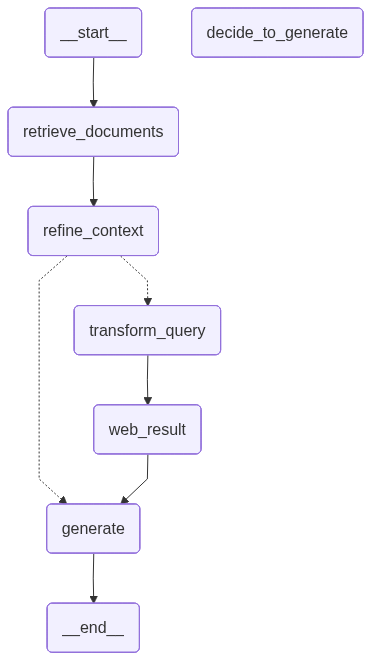

In [166]:
graph=StateGraph(rag)
graph.add_node('retrieve_documents', retrieve_documents)
graph.add_node('refine_context', refine_context)
graph.add_node('web_result', web_search)
graph.add_node('generate', generate)
graph.add_node('transform_query', transform_query)
graph.add_node('decide_to_generate', decide_to_generate)
graph.add_edge(START,'retrieve_documents')
graph.add_edge('retrieve_documents','refine_context')

graph.add_conditional_edges('refine_context', decide_to_generate,{'transform_query': 'transform_query', 'generate': 'generate'})
graph.add_edge('transform_query', 'web_result')
graph.add_edge('web_result', 'generate')
graph.add_edge('generate', END)
workflow=graph.compile()
workflow


In [119]:
# from IPython.display import Image, display
# try:
#     display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))
# except Exception:
#     # This requires some extra dependencies and is optional
#     pass

In [164]:
result=workflow.invoke({'question':'who is attention is all you need?'})

---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


In [165]:
result

{'question': 'What is the significance of the "Attention is All You Need" paper in the field of machine learning?',
 'docs': [Document(id='4a8935f8-5e7c-4cd6-873a-9d9bf583ce10', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'attention-is-all-you-need.pdf', 'total_pages': 15, 'page': 2, 'page_label': '3'}, page_content='3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3'),
  Document(id='73588788-c009-4057-8855-8dfb2e31f9c9', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '